### **Libaray**

In [71]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [72]:
df = pd.read_csv(r"/content/pharmace test.csv")
df

,sale_datetime,invoice_no,store_id,region,cashier,customer_type,payment_method,insurance_provider,patient_age,patient_gender,...,batch_no,expiry_date,quantity,unit_price,cost_price_per_unit,discount_pct,total_before_vat,total_vat,total_paid,profit_margin_pct
0,10/16/2025,INV000001,S001,Cairo,Rania,Walk-in,Cash,not insurance,19,F,...,B9279,2/13/2026,1,24.02,14.36,8.28,22.03,3.08,25.11,40.22
1,4/4/2025,INV000002,S003,Alexandria,Youssef,Insurance,Insurance,HealthPlus,45,F,...,B6514,12/30/2025,1,68.29,34.45,24.14,51.80,7.25,59.05,49.55
2,2/14/2024,INV000003,S004,Cairo,Hatem,Walk-in,Insurance,Misr Insurance,45,F,...,B4150,9/11/2024,1,17.77,11.84,22.23,13.82,1.93,15.75,33.37
3,4/13/2024,INV000004,S003,Alexandria,Sara,Walk-in,Cash,not insurance,58,M,...,B2169,5/8/2025,2,8.37,4.55,0.00,16.74,2.34,19.08,45.64
4,4/18/2025,INV000005,S003,Alexandria,Rania,Walk-in,Cash,not insurance,29,F,...,B5386,11/14/2025,1,74.22,34.23,0.00,74.22,10.39,84.61,53.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4/7/2024,INV001996,S001,Cairo,Youssef,Walk-in,Card,not insurance,43,F,...,B1989,8/25/2026,1,7.89,5.64,0.00,7.89,1.10,8.99,28.52
1996,5/31/2024,INV001997,S004,Cairo,Omar,Regular,Card,not insurance,13,M,...,B2035,10/18/2026,1,118.42,80.09,0.00,118.42,16.58,135.00,32.37
1997,5/31/2024,INV001997,S004,Giza,Rania,Regular,Card,not insurance,41,F,...,B1995,12/17/2026,1,14.55,10.68,0.00,14.55,2.04,16.59,26.60
1998,8/16/2025,INV001999,S002,Giza,Ahmed,Walk-in,Card,not insurance,64,F,...,B8130,6/1/2028,1,47.89,30.01,0.00,47.89,6.70,54.59,37.34


# Convert date columns

In [7]:
df['sale_datetime'] = pd.to_datetime(df['sale_datetime'], errors='coerce')
df['expiry_date'] = pd.to_datetime(df['expiry_date'], errors='coerce')

#Remove duplicate


In [35]:
duplicates_count = df.duplicated().sum()
print("Number of exact duplicate rows:", duplicates_count)
df = df.drop_duplicates(keep='first')

Number of exact duplicate rows: 0


In [32]:
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

Empty DataFrame
Columns: [sale_datetime, invoice_no, store_id, region, cashier, customer_type, payment_method, insurance_provider, patient_age, patient_gender, medicine_id, brand_name, generic_name, manufacturer, batch_no, expiry_date, quantity, unit_price, cost_price_per_unit, discount_pct, total_before_vat, total_vat, total_paid, profit_margin_pct, total_check]
Index: []

[0 rows x 25 columns]


# Check missing values


In [11]:
missing = df.isnull().sum()
"Missing values per column:"
missing


,0
sale_datetime,0
invoice_no,0
store_id,0
region,0
cashier,0
customer_type,0
payment_method,0
insurance_provider,0
patient_age,0
patient_gender,0


In [13]:
numeric_cols = ['patient_age','unit_price','cost_price_per_unit','discount_pct',
                'total_before_vat','total_vat','total_paid','profit_margin_pct']
for col in numeric_cols:
    df.loc[:, col] = df[col].fillna(df[col].median())

cat_cols = ['region','cashier','customer_type','payment_method','insurance_provider','patient_gender']
for col in cat_cols:
     df.loc[:, col] = df[col].fillna(df[col].mode()[0])


In [15]:
text_cols = ['region','cashier','customer_type','payment_method','insurance_provider',
             'patient_gender','brand_name','generic_name','manufacturer','batch_no']

for col in text_cols:
    df.loc[:, col] = df[col].astype(str).str.strip().str.lower()

# Fix unrealistic ages



In [16]:
median_age = df['patient_age'].median()

df.loc[(df['patient_age'] == 0) | (df['patient_age'] > 100), 'patient_age'] = median_age

# Handle outliers in numeric columns


In [47]:
for col in ['unit_price', 'total_before_vat', 'total_paid']:
    upper_limit = df[col].quantile(0.999)
    df.loc[df[col] > upper_limit, col] = upper_limit
df['calculated_with_discount'] = (df['unit_price'] * df['quantity']) * (1 - df['discount_pct']/100)

In [41]:
if 'quantity' in df.columns:
    df['expected_total'] = (df['unit_price'] * df['quantity']) + df['total_vat'] - df['discount_pct']
else:
    df['expected_total'] = df['unit_price'] + df['total_vat']

# Feature Engineering


In [20]:
df['total_check'] = df['total_before_vat'] + df['total_vat']
df.loc[df['total_check'].round(2) != df['total_paid'].round(2), 'total_paid'] = df['total_check']



# after cleaning


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1655 entries, 0 to 1999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   sale_datetime        1655 non-null   datetime64[ns]
 1   invoice_no           1655 non-null   object        
 2   store_id             1655 non-null   object        
 3   region               1655 non-null   object        
 4   cashier              1655 non-null   object        
 5   customer_type        1655 non-null   object        
 6   payment_method       1655 non-null   object        
 7   insurance_provider   1655 non-null   object        
 8   patient_age          1655 non-null   float64       
 9   patient_gender       1655 non-null   object        
 10  medicine_id          1655 non-null   object        
 11  brand_name           1655 non-null   object        
 12  generic_name         1655 non-null   object        
 13  manufacturer         1655 non-null   o

In [23]:
df.describe()

,sale_datetime,patient_age,expiry_date,quantity,unit_price,cost_price_per_unit,discount_pct,total_before_vat,total_vat,total_paid,profit_margin_pct,total_check
count,1655,1655.000000,1655,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000
mean,2024-12-02 20:49:27.009063168,39.735347,2026-07-20 06:11:31.722054656,1.358912,53.429420,33.100981,4.620254,64.185025,8.985797,73.170823,37.580689,73.170823
min,2024-01-01 00:00:00,1.000000,2024-04-08 00:00:00,1.000000,4.520000,2.290000,0.000000,3.620000,0.510000,4.130000,19.970000,4.130000
25%,2024-06-11 00:00:00,28.000000,2025-11-01 12:00:00,1.000000,16.465000,10.290000,0.000000,20.085000,2.810000,22.895000,28.450000,22.895000
50%,2024-11-29 00:00:00,39.000000,2026-08-01 00:00:00,1.000000,34.950000,21.630000,0.000000,42.420000,5.940000,48.360000,37.850000,48.360000
75%,2025-05-24 12:00:00,51.000000,2027-04-12 00:00:00,2.000000,77.290000,48.045000,8.820000,91.835000,12.855000,104.690000,46.370000,104.690000
max,2025-11-09 00:00:00,89.000000,2028-10-21 00:00:00,5.000000,198.566441,124.261127,24.940000,237.128464,33.197640,270.326102,54.990000,270.326104
std,NaN,16.940005,NaN,0.698420,48.185869,30.110540,7.500375,57.622689,8.067100,65.689788,10.221489,65.689788


In [26]:
df.head(5)

,sale_datetime,invoice_no,store_id,region,cashier,customer_type,payment_method,insurance_provider,patient_age,patient_gender,...,expiry_date,quantity,unit_price,cost_price_per_unit,discount_pct,total_before_vat,total_vat,total_paid,profit_margin_pct,total_check
0,2025-10-16,INV000001,S001,cairo,rania,walk-in,cash,not insurance,19.0,f,...,2026-02-13,1,24.02,14.36,8.28,22.03,3.08,25.11,40.22,25.11
1,2025-04-04,INV000002,S003,alexandria,youssef,insurance,insurance,healthplus,45.0,f,...,2025-12-30,1,68.29,34.45,24.14,51.80,7.25,59.05,49.55,59.05
2,2024-02-14,INV000003,S004,cairo,hatem,walk-in,insurance,misr insurance,45.0,f,...,2024-09-11,1,17.77,11.84,22.23,13.82,1.93,15.75,33.37,15.75
3,2024-04-13,INV000004,S003,alexandria,sara,walk-in,cash,not insurance,58.0,m,...,2025-05-08,2,8.37,4.55,0.00,16.74,2.34,19.08,45.64,19.08
4,2025-04-18,INV000005,S003,alexandria,rania,walk-in,cash,not insurance,29.0,f,...,2025-11-14,1,74.22,34.23,0.00,74.22,10.39,84.61,53.88,84.61


# Exploratory Data Analysis EDA

# Distribution of numeric variables

<Figure size 1200x600 with 0 Axes>

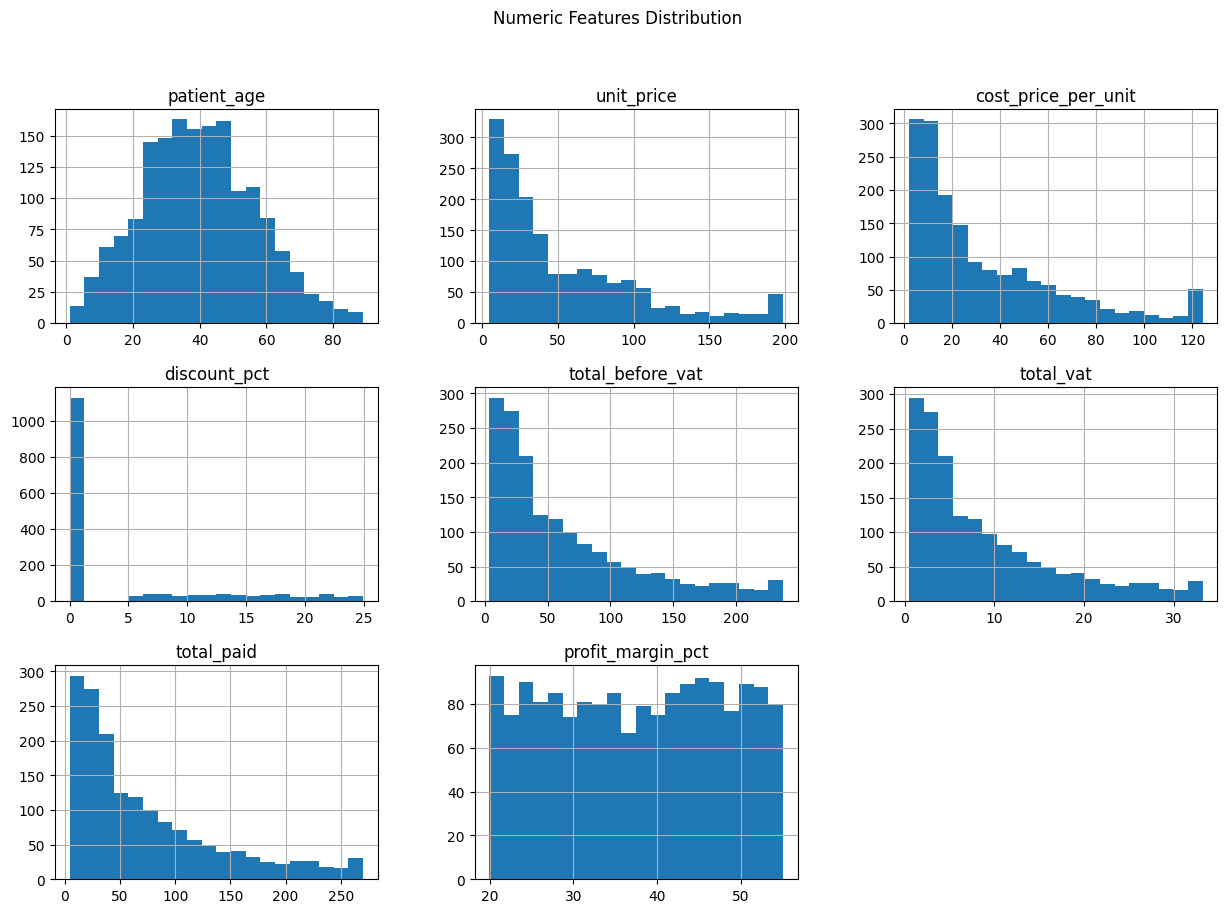

In [27]:
plt.figure(figsize=(12,6))
df[numeric_cols].hist(bins=20, figsize=(15,10), layout=(3,3))
plt.suptitle("Numeric Features Distribution")
plt.show()

# Categorical counts

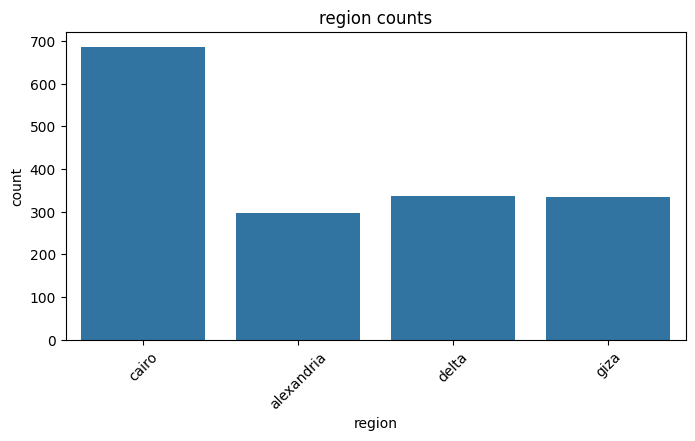

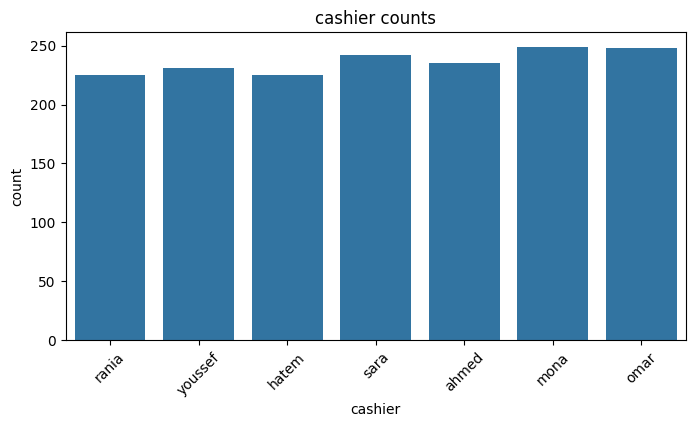

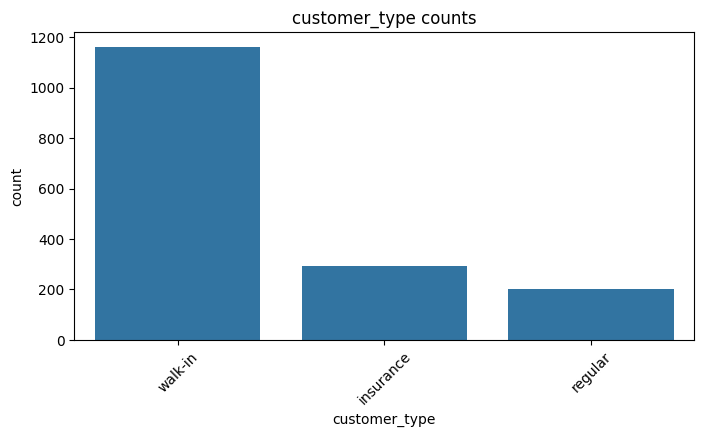

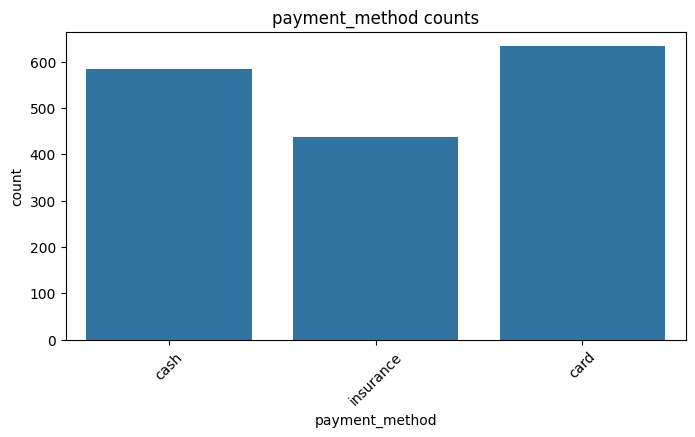

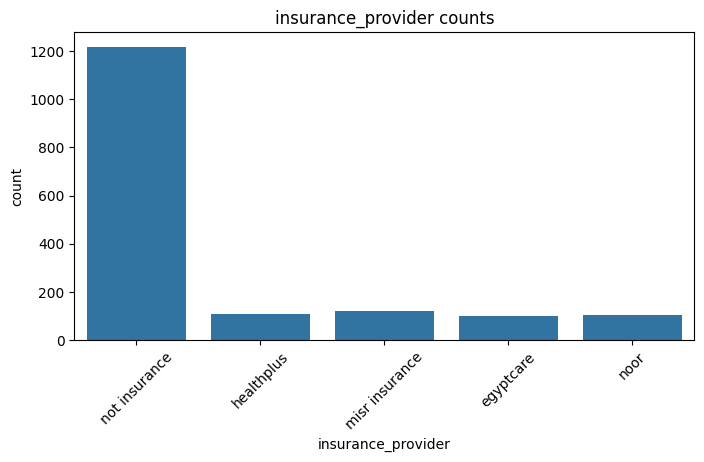

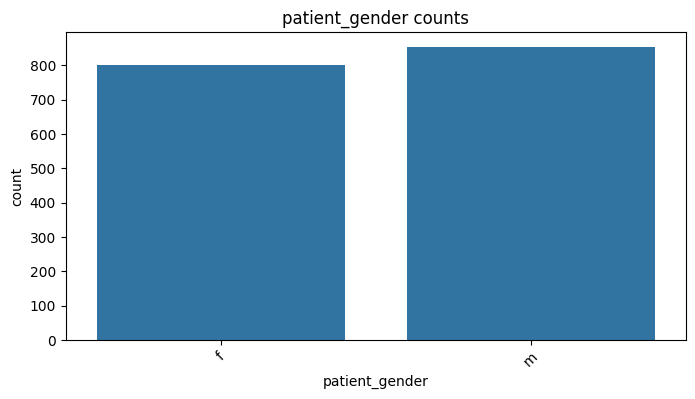

In [28]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.title(f"{col} counts")
    plt.xticks(rotation=45)
    plt.show()

# Correlation matrix

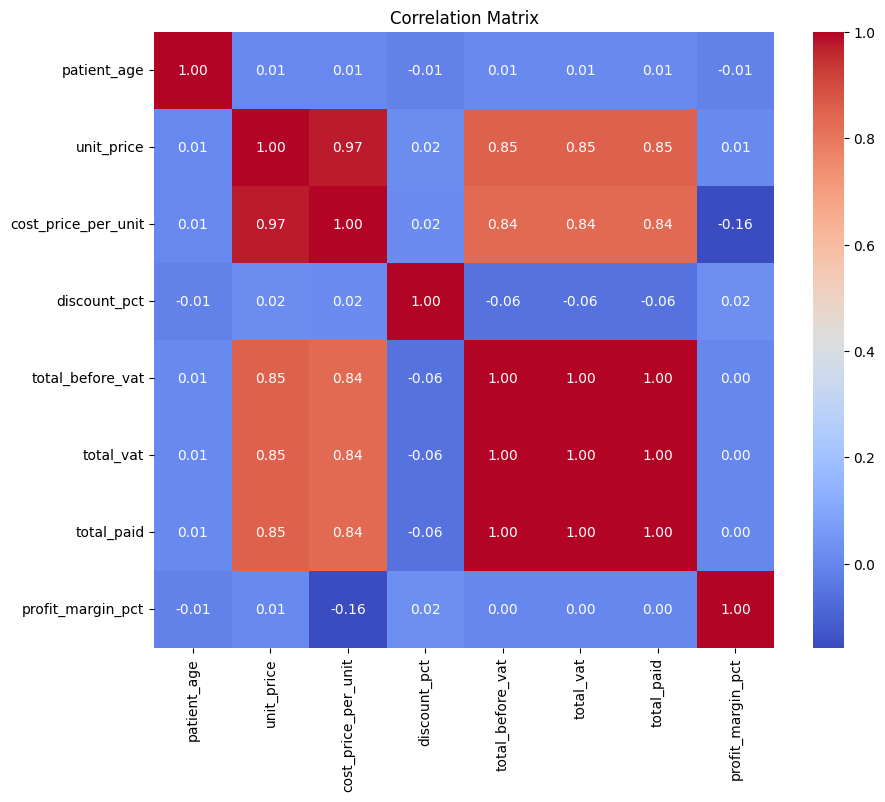

In [29]:
plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# relationship between unit price and total paid

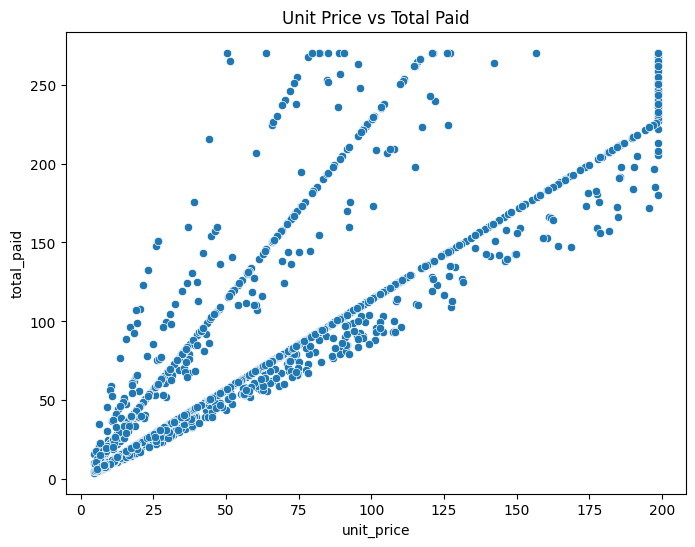

In [51]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='unit_price', y='total_paid', data=df)
plt.title("Unit Price vs Total Paid")
plt.show()


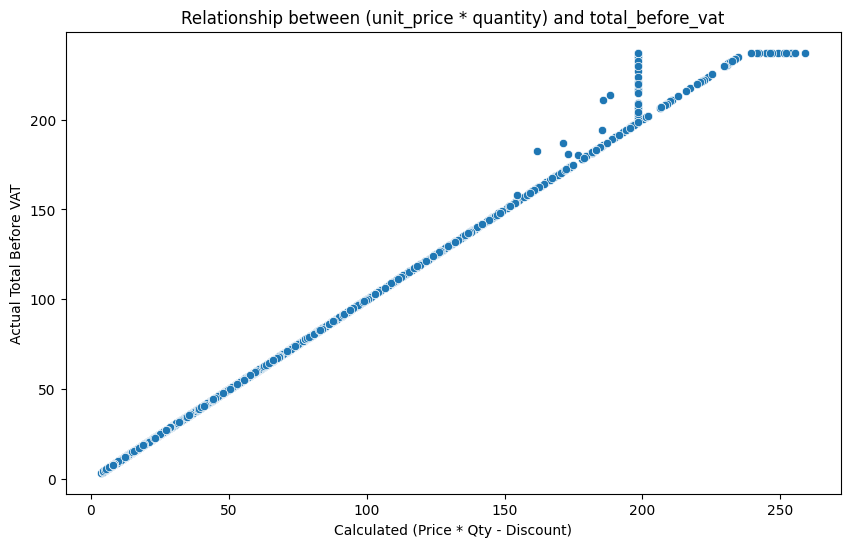

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='calculated_with_discount', y='total_before_vat')
plt.title("Relationship between (unit_price * quantity) and total_before_vat")
plt.xlabel("Calculated (Price * Qty - Discount)")
plt.ylabel("Actual Total Before VAT")
plt.show()

# average total paid by customer type

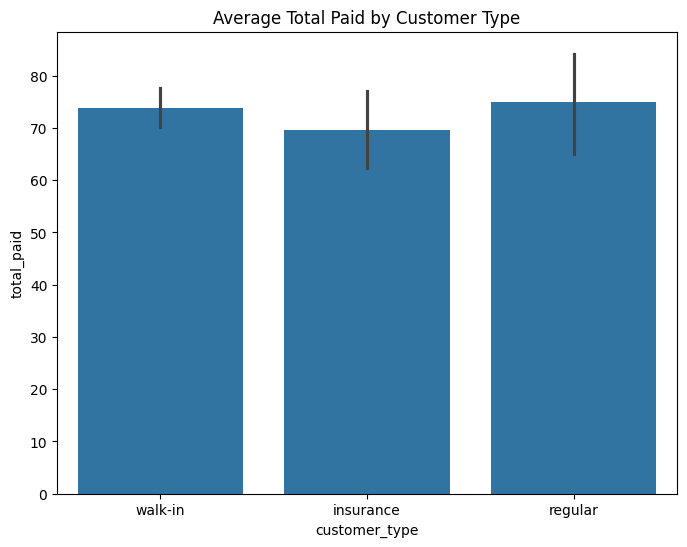

In [50]:
plt.figure(figsize=(8,6))
sns.barplot(x='customer_type', y='total_paid', data=df)
plt.title("Average Total Paid by Customer Type")
plt.show()

# Drop Unnecessary Columns

In [52]:
cols_to_drop = ['invoice_no', 'batch_no', 'sale_datetime']
df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Encode Categorical Variables

In [57]:
# 2. Encode Categorical Variables
cat_cols = ['region','cashier','payment_method','insurance_provider','patient_gender',
            'brand_name','generic_name','manufacturer']

le_dict = {}
for col in cat_cols:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le

# Encode Target for Classification
if 'customer_type' in df_model.columns:
    le_target = LabelEncoder()
    df_model['customer_type'] = le_target.fit_transform(df_model['customer_type'].astype(str))


# 3. Define Features & Target (Fixing the NameError)
# Classification: Predict customer_type
X_clf = df_model.drop('customer_type', axis=1)
y_clf = df_model['customer_type']

# Regression: Predict total_paid
# Drop leaking columns (total_before_vat, total_vat)
X_reg = df_model.drop(['total_paid', 'total_before_vat', 'total_vat'], axis=1)
y_reg = df_model['total_paid']

#  Split Train/Test

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("Data Split Successfully!")
print(f"X_reg shape: {Xr_train.shape}")
print(f"X_clf shape: {Xc_train.shape}")

Data Split Successfully!
X_reg shape: (1324, 25)
X_clf shape: (1324, 27)


# Identify numeric columns for scaling
# Note: excluding targets and already encoded categorical columns if possible

In [61]:
numeric_cols = ['patient_age', 'unit_price', 'cost_price_per_unit', 'discount_pct', 'quantity', 'profit_margin_pct']

scaler = StandardScaler()

# Scaling for Classification
Xc_train[numeric_cols] = scaler.fit_transform(Xc_train[numeric_cols])
Xc_test[numeric_cols] = scaler.transform(Xc_test[numeric_cols])

# Scaling for Regression
Xr_train[numeric_cols] = scaler.fit_transform(Xr_train[numeric_cols])
Xr_test[numeric_cols] = scaler.transform(Xr_test[numeric_cols])

print("Scaling Completed.")

Scaling Completed.


# Classification

In [65]:
# 1. Keep only numeric columns in X_clf and X_reg
# This will automatically remove invoice_no, sale_datetime, and any other strings
X_clf_final = X_clf.select_dtypes(include=[np.number])
X_reg_final = X_reg.select_dtypes(include=[np.number])

# 2. Re-split the data with the cleaned features
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf_final, y_clf, test_size=0.2, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg_final, y_reg, test_size=0.2, random_state=42)

# 3. Apply Scaling again on the new split
scaler = StandardScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

Xr_train_scaled = scaler.fit_transform(Xr_train)
Xr_test_scaled = scaler.transform(Xr_test)

print("Cleaned! Ready to train.")

# 4. Run Classification again
print("=== Classification Results ===")
for name, model in models_clf.items():
    model.fit(Xc_train_scaled, yc_train)
    y_pred = model.predict(Xc_test_scaled)
    print(f"{name} Accuracy: {accuracy_score(yc_test, y_pred):.3f}")

Cleaned! Ready to train.
=== Classification Results ===
Logistic Regression Accuracy: 0.795
Decision Tree Accuracy: 0.785
Random Forest Accuracy: 0.804
SVM Accuracy: 0.795


#  Regression

In [70]:

# Define Regression Models
models_reg = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

print("=== Regression Results: Predicting total_paid ===")
for name, model in models_reg.items():
    # Training on scaled regression data
    model.fit(Xr_train_scaled, yr_train)


    # Predicting
    y_pred = model.predict(Xr_test_scaled)

    # Evaluation
    r_squared = r2_score(yr_test, y_pred)
    mae = mean_absolute_error(yr_test, y_pred)

    print(f"\n>>> {name}:")
    print(f"    R2 Score (Accuracy): {r_squared:.4f}")
    print(f"    Mean Absolute Error: {mae:.2f} SAR") # Assuming currency is SAR

=== Regression Results: Predicting total_paid ===

>>> Linear Regression:
    R2 Score (Accuracy): 1.0000
    Mean Absolute Error: 0.00 SAR

>>> Random Forest Regressor:
    R2 Score (Accuracy): 0.9999
    Mean Absolute Error: 0.22 SAR


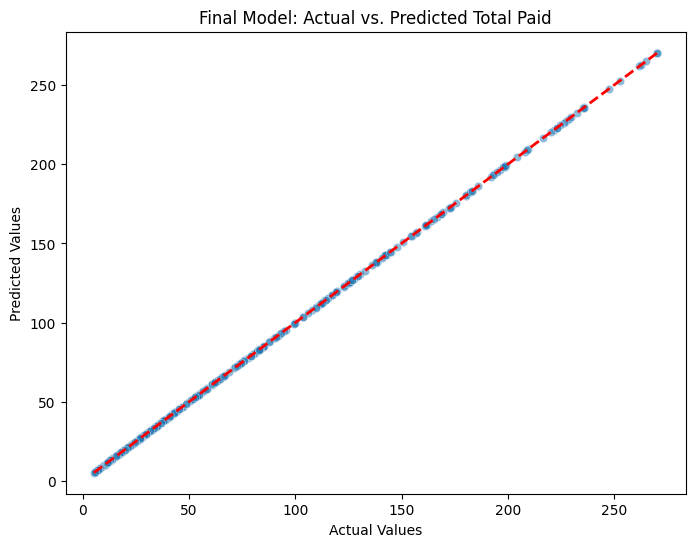

In [68]:


# Let's visualize the Linear Regression predictions
model_final = LinearRegression()
model_final.fit(Xr_train_scaled, yr_train)
y_final_pred = model_final.predict(Xr_test_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=yr_test, y=y_final_pred, alpha=0.5)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], '--r', linewidth=2)
plt.title('Final Model: Actual vs. Predicted Total Paid')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()